## 서울특별시 아파트(매매) 실거래가 데이터 분석
### 데이터마이닝 기말 프로젝트 과제
자료제공 : 국토교통부




## 1) 데이터 불러오기 및 병합

In [1]:
# 1차 라이브러리 불러오기 (외부 패키지가 설치가 제한된 환경으로 기본 패키지 위주로 사용)
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 폴더 경로 불러오기
path = r"C:\Users\INSIGHT\Desktop\DB\아파트 실거래가"
os.listdir(path)

['아파트(매매)_실거래가_20260519085455.xlsx',
 '아파트(매매)_실거래가_20260519085944.xlsx',
 '아파트(매매)_실거래가_20260519085951.xlsx',
 '아파트(매매)_실거래가_20260519090006.xlsx',
 '아파트(매매)_실거래가_20260519090018.xlsx',
 '아파트(매매)_실거래가_20260519090029.xlsx',
 '아파트(매매)_실거래가_20260519090044.xlsx',
 '아파트(매매)_실거래가_20260519090302.xlsx',
 '아파트(매매)_실거래가_20260519090320.xlsx',
 '아파트(매매)_실거래가_20260519090332.xlsx']

In [3]:
# 엑셀 파일 목록 가져오기
file_list = glob.glob(os.path.join(path, "*.xlsx"))
file_list

['C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519085455.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519085944.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519085951.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519090006.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519090018.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519090029.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519090044.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519090302.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519090320.xlsx',
 'C:\\Users\\INSIGHT\\Desktop\\DB\\아파트 실거래가\\아파트(매매)_실거래가_20260519090332.xlsx']

In [4]:
# 비어있는 리스트 생성
df_list = []

# 파일 반복
for file in file_list:

    # 처음 12행 제거 후 읽기
    temp_df = pd.read_excel(file, skiprows=12)

    df_list.append(temp_df)

# 데이터 합치기
df = pd.concat(df_list, ignore_index=True)

# 통합 저장
df.to_csv(
    r"C:\Users\INSIGHT\Desktop\DB\분석용 통합 데이터.csv",
    index=False,
    encoding='utf-8-sig'
)

"파일 통합 및 저장 완료"

c:\Users\INSIGHT\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\INSIGHT\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\INSIGHT\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\INSIGHT\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply o

'파일 통합 및 저장 완료'

## 2) 전처리

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 716214 entries, 0 to 716213
Data columns (total 21 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   NO        716214 non-null  int64  
 1   시군구       716214 non-null  str    
 2   번지        716214 non-null  str    
 3   본번        716214 non-null  int64  
 4   부번        716214 non-null  int64  
 5   단지명       716214 non-null  str    
 6   전용면적(㎡)   716214 non-null  float64
 7   계약년월      716214 non-null  int64  
 8   계약일       716214 non-null  int64  
 9   거래금액(만원)  716214 non-null  str    
 10  동         716214 non-null  str    
 11  층         716214 non-null  int64  
 12  매수자       716214 non-null  str    
 13  매도자       716214 non-null  str    
 14  건축년도      716214 non-null  int64  
 15  도로명       716214 non-null  str    
 16  해제사유발생일   716214 non-null  str    
 17  거래유형      716214 non-null  str    
 18  중개사소재지    716214 non-null  str    
 19  등기일자      716214 non-null  str    
 20  주택유형      71621

In [6]:
df.shape

(716214, 21)

In [7]:
df.head(10)

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형
0,1,서울특별시 중구 신당동,840,840,0,현대,79.11,202501,1,"92,000",...,15,개인,개인,1993,다산로36길 109,-,중개거래,서울 중구,25.03.20,아파트
1,2,서울특별시 성동구 행당동,347,347,0,대림e-편한세상,114.94,202501,1,"156,000",...,6,개인,개인,2000,행당로 79,-,중개거래,서울 성동구,25.03.28,아파트
2,3,서울특별시 성북구 동소문동4가,279,279,0,송산아파트,58.59,202501,1,"53,000",...,14,개인,개인,1998,동소문로3길 101,-,중개거래,서울 성북구,25.04.02,아파트
3,4,서울특별시 노원구 공릉동,91,91,0,청솔아파트8,84.65,202501,1,"68,000",...,4,개인,개인,2000,노원로1가길 10,-,중개거래,서울 노원구,25.02.26,아파트
4,5,서울특별시 성북구 돈암동,632,632,0,돈암동 풍림아파트 101~105동,84.68,202501,1,"64,900",...,8,개인,개인,1999,북악산로 913,-,중개거래,서울 성북구,25.05.30,아파트
5,6,서울특별시 양천구 목동,902,902,0,목동신시가지2,152.64,202501,1,"311,500",...,3,개인,개인,1986,목동서로 70,-,중개거래,서울 양천구,25.02.03,아파트
6,7,서울특별시 구로구 신도림동,645,645,0,동아3,60.00,202501,1,"102,000",...,11,개인,개인,2000,신도림로 78,-,중개거래,서울 구로구,25.02.03,아파트
7,8,서울특별시 영등포구 양평동5가,76,76,0,양평한신,59.94,202501,1,"85,500",...,5,개인,개인,1996,양평로24길 9,-,중개거래,서울 영등포구,25.02.28,아파트
8,9,서울특별시 강서구 가양동,1475,1475,0,강변,34.44,202501,1,"52,000",...,10,개인,개인,1992,허준로 139,-,중개거래,서울 강서구,25.04.09,아파트
9,10,서울특별시 영등포구 양평동3가,90-1,90,1,거성파스텔,131.34,202501,1,"119,800",...,8,개인,개인,1999,선유로43가길 24,-,중개거래,서울 영등포구,25.03.21,아파트


In [8]:
df.tail(5)

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),...,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형
716209,115971,서울특별시 서초구 잠원동,53,53,0,현대,84.87,201501,31,"83,500",...,18,-,-,1993,잠원로12길 4,-,-,-,-,아파트
716210,115972,서울특별시 서초구 잠원동,53,53,0,현대,84.87,201501,31,"79,600",...,14,-,-,1993,잠원로12길 4,-,-,-,-,아파트
716211,115973,서울특별시 강남구 일원동,614,614,0,현대4,73.00,201501,31,"60,000",...,5,-,-,1987,개포로110길 21,-,-,-,-,아파트
716212,115974,서울특별시 송파구 잠실동,22,22,0,리센츠,124.22,201501,31,"135,000",...,3,-,-,2008,올림픽로 135,-,-,-,-,아파트
716213,115975,서울특별시 송파구 잠실동,35,35,0,트리지움,149.45,201501,31,"157,000",...,10,-,-,2007,잠실로 62,-,-,-,-,아파트


In [9]:
df['거래금액(만원)'].dtype

<StringDtype(storage='python', na_value=nan)>

In [10]:
df['거래금액(만원)'].head(10)

0     92,000
1    156,000
2     53,000
3     68,000
4     64,900
5    311,500
6    102,000
7     85,500
8     52,000
9    119,800
Name: 거래금액(만원), dtype: str

In [11]:
# 거래금액 정수형으로 바꾸기
df['거래금액(만원)'] = (
    df['거래금액(만원)']
    .str.replace(',', '', regex=False)
    .astype(int)
)

In [12]:
# 확인
df['거래금액(만원)'].head(5)

0     92000
1    156000
2     53000
3     68000
4     64900
Name: 거래금액(만원), dtype: int64

In [13]:
df.columns

Index(['NO', '시군구', '번지', '본번', '부번', '단지명', '전용면적(㎡)', '계약년월', '계약일',
       '거래금액(만원)', '동', '층', '매수자', '매도자', '건축년도', '도로명', '해제사유발생일', '거래유형',
       '중개사소재지', '등기일자', '주택유형'],
      dtype='str')

In [14]:
'평단가(만원)' in df.columns

False

In [15]:
df['거래금액(만원)'].dtype

dtype('int64')

In [16]:
# 평수 컬럼 생성
df['평수'] = (df['전용면적(㎡)'] / 3.305785).round(2)

# 거래금액 컬럼 위치 찾기
거래금액위치 = df.columns.get_loc('거래금액(만원)')

# 평단가 컬럼 삽입
df.insert(
    거래금액위치 + 1,
    '평단가(만원)',
    (df['거래금액(만원)'] / df['평수']).round(0)
)

In [17]:
df['평수']

0         23.93
1         34.77
2         17.72
3         25.61
4         25.62
          ...  
716209    25.67
716210    25.67
716211    22.08
716212    37.58
716213    45.21
Name: 평수, Length: 716214, dtype: float64

In [18]:
# 기존 컬럼 삭제 (해당 컬럼은 Run All로 실행해도 그냥 통과함) idenpotent하다 : 여러 번 실행해도 안전 
df.drop(columns=['시', '구', '지역동'], inplace=True, errors='ignore')

# 시군구 분리
split_df = df['시군구'].str.split(' ', expand=True)

# 컬럼명 지정
split_df.columns = ['시', '구', '지역동']

# 시군구 컬럼 위치 찾기
idx = df.columns.get_loc('시군구')

# 시군구 옆에 컬럼 추가
df.insert(idx + 1, '시', split_df['시'])
df.insert(idx + 2, '구', split_df['구'])
df.insert(idx + 3, '지역동', split_df['지역동'])

# 확인
df.head()

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수
0,1,서울특별시 중구 신당동,서울특별시,중구,신당동,840,840,0,현대,79.11,...,개인,개인,1993,다산로36길 109,-,중개거래,서울 중구,25.03.20,아파트,23.93
1,2,서울특별시 성동구 행당동,서울특별시,성동구,행당동,347,347,0,대림e-편한세상,114.94,...,개인,개인,2000,행당로 79,-,중개거래,서울 성동구,25.03.28,아파트,34.77
2,3,서울특별시 성북구 동소문동4가,서울특별시,성북구,동소문동4가,279,279,0,송산아파트,58.59,...,개인,개인,1998,동소문로3길 101,-,중개거래,서울 성북구,25.04.02,아파트,17.72
3,4,서울특별시 노원구 공릉동,서울특별시,노원구,공릉동,91,91,0,청솔아파트8,84.65,...,개인,개인,2000,노원로1가길 10,-,중개거래,서울 노원구,25.02.26,아파트,25.61
4,5,서울특별시 성북구 돈암동,서울특별시,성북구,돈암동,632,632,0,돈암동 풍림아파트 101~105동,84.68,...,개인,개인,1999,북악산로 913,-,중개거래,서울 성북구,25.05.30,아파트,25.62


In [19]:
# 중복제거를 한 후에 남는 고유값
df.nunique()

NO          115975
시군구            338
시                1
구               25
지역동            336
번지            6565
본번            1536
부번             330
단지명           7765
전용면적(㎡)      13995
계약년월           121
계약일             31
거래금액(만원)      8619
평단가(만원)      12477
동             1361
층               73
매수자              5
매도자              5
건축년도            61
도로명           9147
해제사유발생일       1542
거래유형             3
중개사소재지        1720
등기일자           709
주택유형             1
평수            5442
dtype: int64

In [20]:
df.head()

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수
0,1,서울특별시 중구 신당동,서울특별시,중구,신당동,840,840,0,현대,79.11,...,개인,개인,1993,다산로36길 109,-,중개거래,서울 중구,25.03.20,아파트,23.93
1,2,서울특별시 성동구 행당동,서울특별시,성동구,행당동,347,347,0,대림e-편한세상,114.94,...,개인,개인,2000,행당로 79,-,중개거래,서울 성동구,25.03.28,아파트,34.77
2,3,서울특별시 성북구 동소문동4가,서울특별시,성북구,동소문동4가,279,279,0,송산아파트,58.59,...,개인,개인,1998,동소문로3길 101,-,중개거래,서울 성북구,25.04.02,아파트,17.72
3,4,서울특별시 노원구 공릉동,서울특별시,노원구,공릉동,91,91,0,청솔아파트8,84.65,...,개인,개인,2000,노원로1가길 10,-,중개거래,서울 노원구,25.02.26,아파트,25.61
4,5,서울특별시 성북구 돈암동,서울특별시,성북구,돈암동,632,632,0,돈암동 풍림아파트 101~105동,84.68,...,개인,개인,1999,북악산로 913,-,중개거래,서울 성북구,25.05.30,아파트,25.62


In [21]:
print(df['전용면적(㎡)'].min())
print(df['전용면적(㎡)'].max())

10.02
424.32


In [22]:
df['거래금액(만원)'].head(10)

0     92000
1    156000
2     53000
3     68000
4     64900
5    311500
6    102000
7     85500
8     52000
9    119800
Name: 거래금액(만원), dtype: int64

In [23]:
df['거래금액(만원)']

0          92000
1         156000
2          53000
3          68000
4          64900
           ...  
716209     83500
716210     79600
716211     60000
716212    135000
716213    157000
Name: 거래금액(만원), Length: 716214, dtype: int64

In [24]:
# 해당 컬럼이 str type 이여서 오류가 난거임
print(df['거래금액(만원)'].min())
print(df['거래금액(만원)'].max())

700
2500000


In [25]:
# 매매가 가장 높은 가격과 낮은 가격 비교
print(df['거래금액(만원)'].min())
print(df['거래금액(만원)'].max())

700
2500000


In [26]:
# 최고 거래금액 행 찾기
max_row = df.loc[df['거래금액(만원)'].idxmax()]
max_row 

NO                  18243
시군구         서울특별시 용산구 한남동
시                   서울특별시
구                     용산구
지역동                   한남동
번지                    829
본번                    829
부번                      0
단지명                 나인원한남
전용면적(㎡)          273.9424
계약년월               202408
계약일                    13
거래금액(만원)          2500000
평단가(만원)           30168.0
동                    104동
층                       1
매수자                    개인
매도자                    개인
건축년도                 2019
도로명               한남대로 91
해제사유발생일                 -
거래유형                 중개거래
중개사소재지             서울 용산구
등기일자             25.07.01
주택유형                  아파트
평수                  82.87
Name: 18242, dtype: object

In [27]:
# 최고 금액 아파트의 전체 거래내역 보기
나인원_df = max_row['단지명']
나인원_same_df = df[df['단지명'] == 나인원_df]
# 거래연월 기준 정렬
나인원_same_df = 나인원_same_df.sort_values('계약년월')

나인원_same_df

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수
137171,32166,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,244.3478,...,-,-,2019,한남대로 91,-,-,-,-,아파트,73.92
132374,27369,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,244.3478,...,-,-,2019,한남대로 91,-,-,-,-,아파트,73.92
129788,24783,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,206.8953,...,-,-,2019,한남대로 91,-,-,-,-,아파트,62.59
131572,26567,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,206.8953,...,-,-,2019,한남대로 91,-,-,-,-,아파트,62.59
129789,24784,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,206.8953,...,-,-,2019,한남대로 91,-,-,-,-,아파트,62.59
127912,22907,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,206.8953,...,-,-,2019,한남대로 91,-,-,-,-,아파트,62.59
130025,25020,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,206.8953,...,-,-,2019,한남대로 91,-,-,-,-,아파트,62.59
119374,14369,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,206.8953,...,-,-,2019,한남대로 91,-,-,-,-,아파트,62.59
109968,4963,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,273.4125,...,-,-,2019,한남대로 91,-,-,-,-,아파트,82.71
107260,2255,서울특별시 용산구 한남동,서울특별시,용산구,한남동,829,829,0,나인원한남,244.3478,...,-,-,2019,한남대로 91,-,중개거래,서울 용산구,-,아파트,73.92


In [28]:
# 최저 거래금액 행 찾기
min_row = df.loc[df['거래금액(만원)'].idxmin()]
min_row

NO                    68709
시군구         서울특별시 성동구 하왕십리동
시                     서울특별시
구                       성동구
지역동                   하왕십리동
번지                     1066
본번                     1066
부번                        0
단지명                텐즈힐(1단지)
전용면적(㎡)               84.96
계약년월                 201505
계약일                      29
거래금액(만원)                700
평단가(만원)                27.0
동                         -
층                         9
매수자                       -
매도자                       -
건축년도                   2015
도로명                  무학로 33
해제사유발생일                   -
거래유형                      -
중개사소재지                    -
등기일자                      -
주택유형                    아파트
평수                     25.7
Name: 668947, dtype: object

In [29]:
텐즈힐_df = min_row['단지명']
텐즈힐_same_df = df[df['단지명'] == 텐즈힐_df]

텐즈힐_same_df

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수
1538,1539,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),72.52,...,개인,개인,2015,무학로 33,-,중개거래,서울 성동구,25.03.24,아파트,21.94
2280,2281,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),148.80,...,개인,개인,2015,무학로 33,-,중개거래,서울 성동구,25.08.29,아파트,45.01
4396,4397,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),129.34,...,개인,개인,2015,무학로 33,-,중개거래,서울 성동구,25.02.18,아파트,39.13
4940,4941,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),84.96,...,개인,개인,2015,무학로 33,-,중개거래,서울 성동구,25.03.05,아파트,25.70
6137,6138,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),59.88,...,개인,개인,2015,무학로 33,-,중개거래,"서울 성동구, 서울 송파구",25.01.24,아파트,18.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670205,69967,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),148.94,...,-,-,2015,무학로 33,-,-,-,-,아파트,45.05
671565,71327,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),84.88,...,-,-,2015,무학로 33,-,-,-,-,아파트,25.68
673630,73392,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),84.88,...,-,-,2015,무학로 33,-,-,-,-,아파트,25.68
679431,79193,서울특별시 성동구 하왕십리동,서울특별시,성동구,하왕십리동,1066,1066,0,텐즈힐(1단지),148.94,...,-,-,2015,무학로 33,-,-,-,-,아파트,45.05


In [30]:
"거래수 : ", len(텐즈힐_same_df)

('거래수 : ', 654)

In [31]:
# 그래프 라이브러리 불러오기
import matplotlib.pyplot as plt 

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

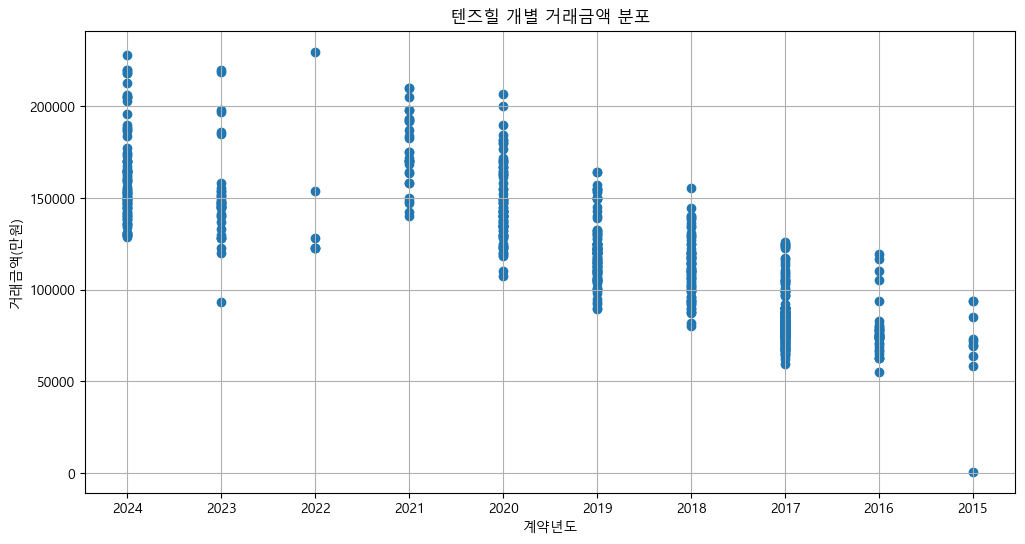

In [32]:
# 계약년도 생성
텐즈힐_same_df = 텐즈힐_same_df.copy()

텐즈힐_same_df['계약년도'] = (
    텐즈힐_same_df['계약년월']
    .astype(str)
    .str[:4]
)

# 그래프 크기
plt.figure(figsize=(12,6))

# 산점도
plt.scatter(
    텐즈힐_same_df['계약년도'],
    텐즈힐_same_df['거래금액(만원)']
)

# 제목
plt.title('텐즈힐 개별 거래금액 분포')

# 축 이름
plt.xlabel('계약년도')
plt.ylabel('거래금액(만원)')

# 격자
plt.grid()

# 출력
plt.show()

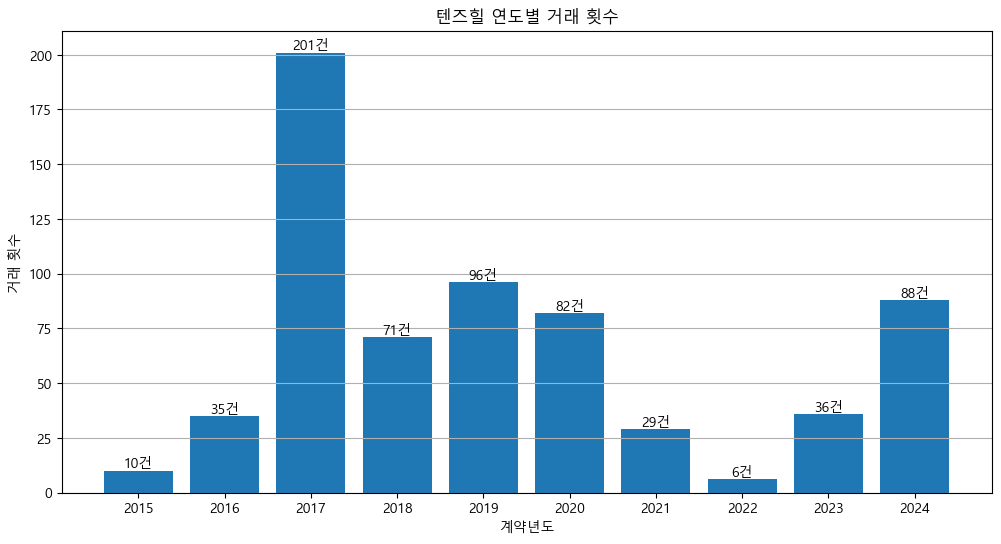

In [33]:
# 복사
텐즈힐_same_df = 텐즈힐_same_df.copy()

# 계약년도 생성
텐즈힐_same_df['계약년도'] = (
    텐즈힐_same_df['계약년월']
    .astype(str)
    .str[:4]
)

# 연도별 거래 횟수 계산
year_count = (
    텐즈힐_same_df['계약년도']
    .value_counts()
    .sort_index()
)

# 그래프 크기
plt.figure(figsize=(12,6))

# 막대그래프
bars = plt.bar(
    year_count.index,
    year_count.values
)

# 값 표시
for bar in bars:
    
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}건',
        ha='center',
        va='bottom'
    )

# 제목
plt.title('텐즈힐 연도별 거래 횟수')

# 축 이름
plt.xlabel('계약년도')
plt.ylabel('거래 횟수')

# 격자
plt.grid(axis='y')

# 출력
plt.show()

In [34]:
텐즈힐_same_df['거래금액(만원)'].max()

np.int64(230000)

In [35]:
df['계약년월'].unique()

array([202501, 202412, 202411, 202410, 202409, 202408, 202407, 202406,
       202405, 202404, 202403, 202402, 202401, 202312, 202311, 202310,
       202309, 202308, 202307, 202306, 202305, 202304, 202303, 202302,
       202301, 202212, 202211, 202210, 202209, 202208, 202207, 202206,
       202205, 202204, 202203, 202202, 202201, 202112, 202111, 202110,
       202109, 202108, 202107, 202106, 202105, 202104, 202103, 202102,
       202101, 202012, 202011, 202010, 202009, 202008, 202007, 202006,
       202005, 202004, 202003, 202002, 202001, 201912, 201911, 201910,
       201909, 201908, 201907, 201906, 201905, 201904, 201903, 201902,
       201901, 201812, 201811, 201810, 201809, 201808, 201807, 201806,
       201805, 201804, 201803, 201802, 201801, 201712, 201711, 201710,
       201709, 201708, 201707, 201706, 201705, 201704, 201703, 201702,
       201701, 201612, 201611, 201610, 201609, 201608, 201607, 201606,
       201605, 201604, 201603, 201602, 201601, 201512, 201511, 201510,
      

In [36]:
df['계약년월'].min()

np.int64(201501)

In [37]:
df['계약년월'].max()

np.int64(202501)

In [38]:
# 시군구별 아파트 거래 count
group_df = df['시군구'].value_counts().reset_index()
group_df

,시군구,count
0,서울특별시 노원구 상계동,26752
1,서울특별시 노원구 중계동,15644
2,서울특별시 양천구 신정동,14567
3,서울특별시 구로구 구로동,14048
4,서울특별시 관악구 봉천동,12923
...,...,...
333,서울특별시 성북구 보문동2가,4
334,서울특별시 종로구 옥인동,4
335,서울특별시 중구 필동1가,4
336,서울특별시 마포구 구수동,3


In [39]:
df.head(5)

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수
0,1,서울특별시 중구 신당동,서울특별시,중구,신당동,840,840,0,현대,79.11,...,개인,개인,1993,다산로36길 109,-,중개거래,서울 중구,25.03.20,아파트,23.93
1,2,서울특별시 성동구 행당동,서울특별시,성동구,행당동,347,347,0,대림e-편한세상,114.94,...,개인,개인,2000,행당로 79,-,중개거래,서울 성동구,25.03.28,아파트,34.77
2,3,서울특별시 성북구 동소문동4가,서울특별시,성북구,동소문동4가,279,279,0,송산아파트,58.59,...,개인,개인,1998,동소문로3길 101,-,중개거래,서울 성북구,25.04.02,아파트,17.72
3,4,서울특별시 노원구 공릉동,서울특별시,노원구,공릉동,91,91,0,청솔아파트8,84.65,...,개인,개인,2000,노원로1가길 10,-,중개거래,서울 노원구,25.02.26,아파트,25.61
4,5,서울특별시 성북구 돈암동,서울특별시,성북구,돈암동,632,632,0,돈암동 풍림아파트 101~105동,84.68,...,개인,개인,1999,북악산로 913,-,중개거래,서울 성북구,25.05.30,아파트,25.62


In [40]:
df['주택유형'].unique()

<StringArray>
['아파트']
Length: 1, dtype: str

In [41]:
# 구별 거래 분석

gu_analysis = (
    df.groupby('구')
    .agg(
        최고거래금액=('거래금액(만원)', 'max'),
        최저거래금액=('거래금액(만원)', 'min'),
        평균거래금액=('거래금액(만원)', 'mean'),
        중앙거래금액=('거래금액(만원)', 'median'),
        거래량=('거래금액(만원)', 'count')
    )
    .reset_index()
)
gu_analysis = (
    df.groupby('구')
    .agg(
        최고거래금액=('거래금액(만원)', 'max'),
        최저거래금액=('거래금액(만원)', 'min'),
        평균거래금액=('거래금액(만원)', 'mean'),
        중앙거래금액=('거래금액(만원)', 'median'),
        거래량=('거래금액(만원)', 'count')
    )
    .reset_index()
)


# 평균 거래금액 반올림
gu_analysis['평균거래금액'] = (
    gu_analysis['평균거래금액']
    .round(0)
    .astype(int)
)
# 평균 거래금액 반올림
gu_analysis['평균거래금액'] = (
    gu_analysis['평균거래금액']
    .round(0)
    .astype(int)
)


# 중앙값 반올림
gu_analysis['중앙거래금액'] = (
    gu_analysis['중앙거래금액']
    .round(0)
    .astype(int)
)




# 최고 거래금액 기준 내림차순 정렬
gu_analysis = gu_analysis.sort_values(
    by='최고거래금액',
    ascending=False
)

# 순위 컬럼 추가
gu_analysis['순위'] = range(1, len(gu_analysis) + 1)

# 컬럼 순서 정리
gu_analysis = gu_analysis[
    [
        '순위',
        '구',
        '최고거래금액',
        '최저거래금액',
        '평균거래금액',
        '중앙거래금액',
        '거래량'
    ]
]

# 확인
gu_analysis

,순위,구,최고거래금액,최저거래금액,평균거래금액,중앙거래금액,거래량
20,1,용산구,2500000,7000,134921,101451,14505
14,2,서초구,1800000,11000,152608,129725,32372
15,3,성동구,1450000,700,90144,77600,28173
0,4,강남구,1450000,12000,153730,130000,41748
23,5,중구,590000,4500,74652,68000,9696
11,6,동작구,570000,9100,75279,68500,27580
19,7,영등포구,555000,1100,72215,60000,31351
17,8,송파구,530000,11000,106615,90000,47428
12,9,마포구,510000,8560,83164,73000,27490
5,10,광진구,420000,5000,83241,72800,14308


### 이상치 확인
박스플롯 (boxplot) : 데이터가 어떻게 퍼져 있는가
1. 중앙값 : 평균보다 이상치 영향 덜 받음
2. 데이터가 몰려있는 범위 
3. 이상치 : 튀는 값

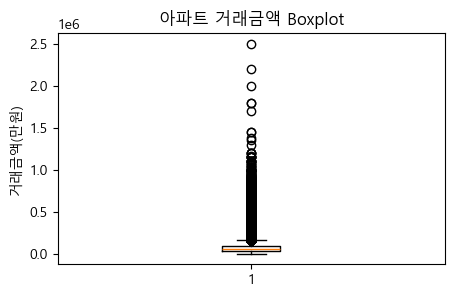

In [42]:
# 그래프 크기
plt.figure(figsize=(5,3))

# 거래금액 박스플롯
plt.boxplot(df['거래금액(만원)'])

# 제목
plt.title('아파트 거래금액 Boxplot')

# y축 이름
plt.ylabel('거래금액(만원)')

# 출력
plt.show()

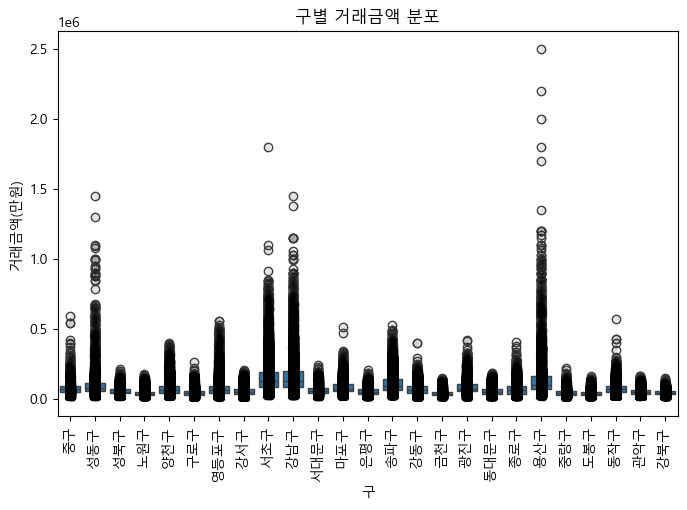

In [43]:


# 그래프 크기
plt.figure(figsize=(8,5))

# Boxplot
sns.boxplot(
    x = '구',
    y = '거래금액(만원)',
    data = df
)

# 개월 데이터 점 표시
sns.stripplot(
    x = '구',
    y = '거래금액(만원)',
    data = df,
    color = 'black',
    alpha  = 0.1
)

# x 세로 회전
plt.xticks(rotation=90)

# 제목
plt.title('구별 거래금액 분포')

# 출력
plt.show()

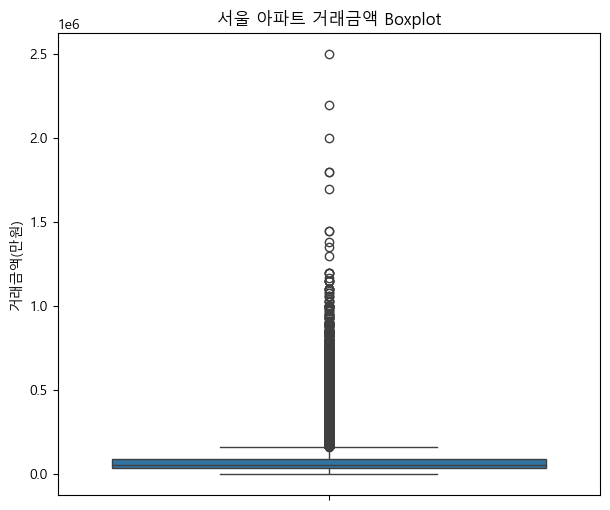

In [44]:
# 그래프 크기
plt.figure(figsize=(7,6))

# 박스플롯
sns.boxplot(
    y=df['거래금액(만원)']
)

# 제목
plt.title('서울 아파트 거래금액 Boxplot')

# y축 이름
plt.ylabel('거래금액(만원)')

# 출력
plt.show()

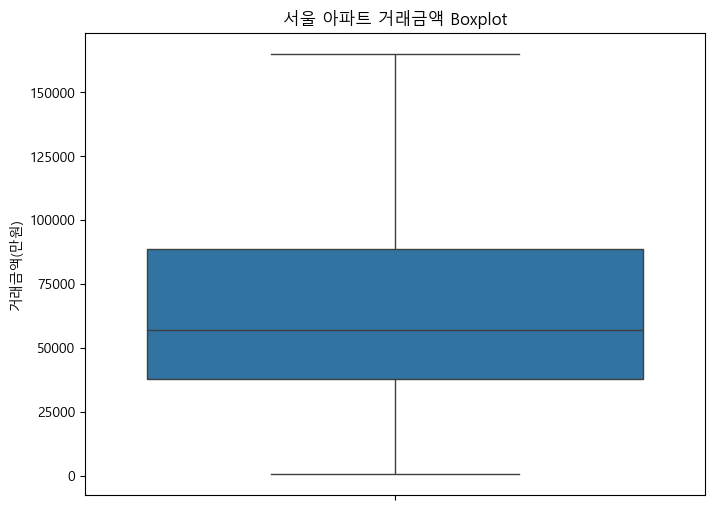

In [45]:
# 그래프 크기
plt.figure(figsize=(8,6))

# Boxplot
sns.boxplot(
    y=df['거래금액(만원)'],
    showfliers=False
)

# 제목
plt.title('서울 아파트 거래금액 Boxplot')

# y축 이름
plt.ylabel('거래금액(만원)')

# 출력
plt.show()

In [46]:
# 서울 데이터용 이상치 제거 함수
def remove_price_outliers(df):

    df_out = pd.DataFrame()

    # 구별로 분석
    for key, subdf in df.groupby('구'):

        mean = np.mean(subdf['거래금액(만원)'])

        std = np.std(subdf['거래금액(만원)'])

        reduced_df = subdf[
            (subdf['거래금액(만원)'] > (mean - std))
            &
            (subdf['거래금액(만원)'] <= (mean + std))
        ]

        df_out = pd.concat(
            [df_out, reduced_df],
            ignore_index=True
        )

    return df_out

df_out = remove_price_outliers(df)

In [47]:
def plot_scatter_chart(df, location):

    temp = df[df['구'] == location]

    plt.figure(figsize=(8,6))

    # 산점도
    plt.scatter(
        temp['전용면적(㎡)'],
        temp['거래금액(만원)'],
        alpha=0.5
    )

    # 회귀선
    sns.regplot(
        x=temp['전용면적(㎡)'],
        y=temp['거래금액(만원)'],
        scatter=False,
        color='red'
    )

    plt.xlabel('전용면적(㎡)')
    plt.ylabel('거래금액(만원)')

    plt.title(f'{location} 면적 대비 거래금액')

    plt.grid()

    plt.show()

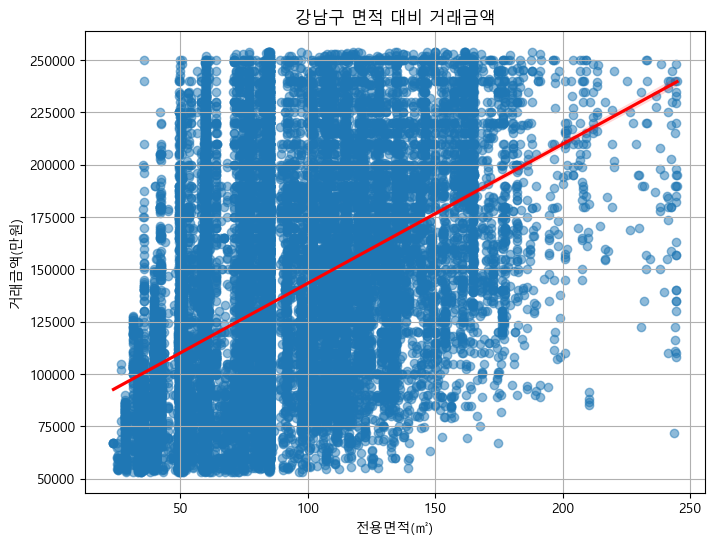

In [48]:
plot_scatter_chart(df_out, '강남구')

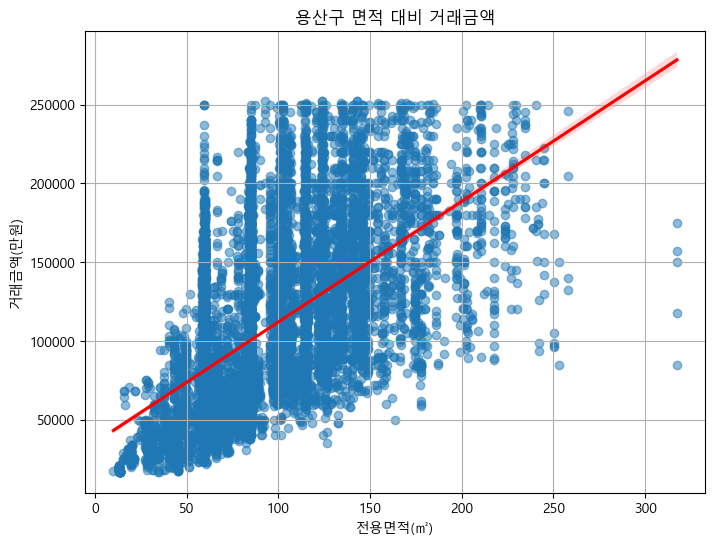

In [49]:
plot_scatter_chart(df_out, '용산구')

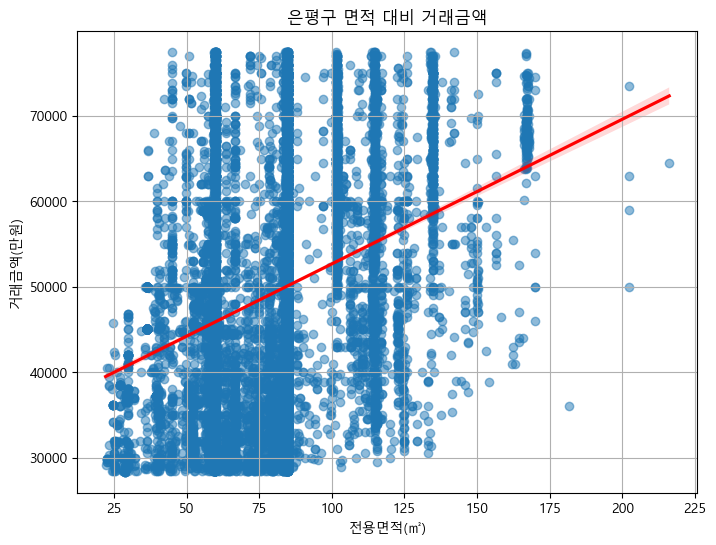

In [50]:
plot_scatter_chart(df_out, '은평구')

In [51]:
# 구별로 아파트시세를 비교해볼지 고민중
df['구'].unique()

<StringArray>
[  '중구',  '성동구',  '성북구',  '노원구',  '양천구',  '구로구', '영등포구',  '강서구',  '서초구',
  '강남구', '서대문구',  '마포구',  '은평구',  '송파구',  '강동구',  '금천구',  '광진구', '동대문구',
  '종로구',  '용산구',  '중랑구',  '도봉구',  '동작구',  '관악구',  '강북구']
Length: 25, dtype: str

In [52]:
# 어느 달에 가장 많이 계약 하는지(입주일 아님) 
# 계약년월 문자열로 변환
df['계약년월'] = df['계약년월'].astype(str)

# 월 컬럼 생성
df['계약월'] = df['계약년월'].str[4:6]

# 월별 거래량 집계
month_count = (
    df.groupby('계약월')
    .size()
    .reset_index(name='거래량')
)

# 거래량 많은 순 정렬
month_count = month_count.sort_values(
    by='거래량',
    ascending=False
)

# 순위 추가
month_count['순위'] = range(1, len(month_count) + 1)

# 컬럼 순서 정리
month_count = month_count[
    [
        '순위',
        '계약월',
        '거래량'
    ]
]

# 결과 확인
month_count

,순위,계약월,거래량
6,1,07,83354
5,2,06,82633
7,3,08,67314
4,4,05,66455
2,5,03,62363
9,6,10,57703
8,7,09,56335
3,8,04,55939
1,9,02,50125
10,10,11,48573


### 구별 평단가 차이

In [71]:
# 구별 평균 평단가 분석

gu_price = (
    df.groupby('구')
    .agg(
        평균평단가=('평단가(만원)', 'mean'),
        중앙평단가=('평단가(만원)', 'median'),
        거래건수=('평단가(만원)', 'count')
    )
    .round(0)
    .astype({
        '평균평단가':'int',
        '중앙평단가':'int',
        '거래건수':'int'
    })
    .reset_index()
)

# 평균 평단가 기준 정렬
gu_price = gu_price.sort_values(
    by='평균평단가',
    ascending=False
)

# 순위 추가
gu_price['순위'] = range(1, len(gu_price)+1)

# 컬럼 순서 변경
gu_price = gu_price[
    ['순위','구','평균평단가','중앙평단가','거래건수']
]

display(gu_price)

# 최고/최저 비교
top_gu = gu_price.iloc[0]
bottom_gu = gu_price.iloc[-1]

print(f'평단가 1위 : {top_gu["구"]}')
print(f'평균 평단가 : {top_gu["평균평단가"]:,} 만원')

print()

print(f'평단가 최하위 : {bottom_gu["구"]}')
print(f'평균 평단가 : {bottom_gu["평균평단가"]:,} 만원')

print()

print(
    f'평단가 차이 : '
    f'{round(top_gu["평균평단가"] / bottom_gu["평균평단가"],2)}배'
)

,순위,구,평균평단가,중앙평단가,거래건수
0,1,강남구,5847,5168,41748
14,2,서초구,5341,4313,32372
17,3,송파구,4352,3831,47428
20,4,용산구,4328,3717,14505
15,5,성동구,3786,3301,28173
12,6,마포구,3584,3130,27490
5,7,광진구,3373,2972,14308
11,8,동작구,3221,2811,27580
1,9,강동구,3164,2756,37623
23,10,중구,3127,2804,9696


평단가 1위 : 강남구
평균 평단가 : 5,847 만원

평단가 최하위 : 도봉구
평균 평단가 : 1,855 만원

평단가 차이 : 3.15배


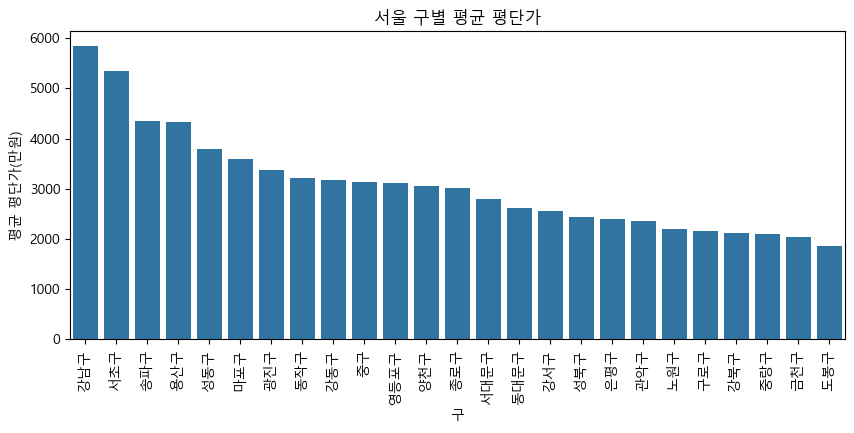

In [75]:
# 일반 막대그래프
plt.figure(figsize=(10,4))

sns.barplot(
    data=gu_price,
    x='구',
    y='평균평단가'
)

plt.xticks(rotation=90)

plt.title('서울 구별 평균 평단가')

plt.xlabel('구')

plt.ylabel('평균 평단가(만원)')

plt.show()

1. KDE = Kernel Density Estimation (커널 밀도 측정) 
- 어디에 데이터가 몰려있는가?
- 부드러운 곡선을 나타내줌

2. 히스토그램
- 데이터 분포를 막대로 표현

3. KDE + 히스토그램
- 데이터가 어떤 분포를 가지는지 시각적을 확인 가능

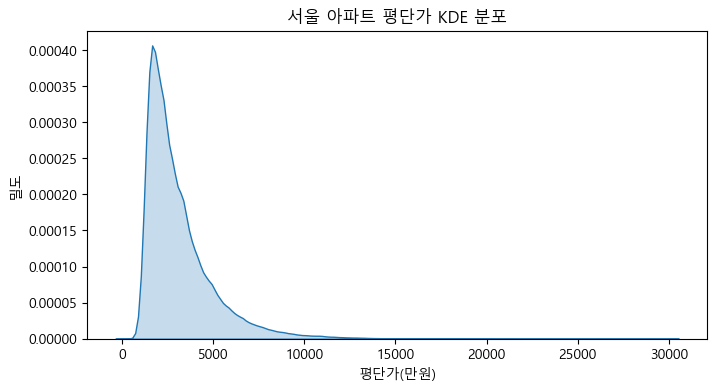

In [135]:
# KDE 그래프

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.kdeplot(
    data=df,
    x='평단가(만원)',
    fill=True
)

plt.title('서울 아파트 평단가 KDE 분포')

plt.xlabel('평단가(만원)')

plt.ylabel('밀도')

plt.show()

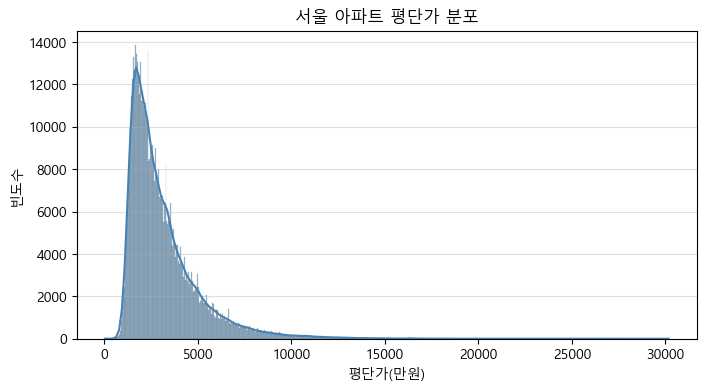

In [138]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='평단가(만원)',
    kde=True,
    color='steelblue'
)

plt.title('서울 아파트 평단가 분포')
plt.xlabel('평단가(만원)')
plt.ylabel('빈도수')

plt.grid(
    axis='y',
    linestyle='-',
    alpha=0.4
)

plt.show()

### ❕아직 잘 모르겠음❕ 특정 시기에 따른 부동산 통계
1. 코로나 이후 부동산 폭등기 : 2020.01~2023
2. 초저금리, 유동성 증가 : 
3. 

In [53]:
df.tail()

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수,계약월
716209,115971,서울특별시 서초구 잠원동,서울특별시,서초구,잠원동,53,53,0,현대,84.87,...,-,1993,잠원로12길 4,-,-,-,-,아파트,25.67,01
716210,115972,서울특별시 서초구 잠원동,서울특별시,서초구,잠원동,53,53,0,현대,84.87,...,-,1993,잠원로12길 4,-,-,-,-,아파트,25.67,01
716211,115973,서울특별시 강남구 일원동,서울특별시,강남구,일원동,614,614,0,현대4,73.00,...,-,1987,개포로110길 21,-,-,-,-,아파트,22.08,01
716212,115974,서울특별시 송파구 잠실동,서울특별시,송파구,잠실동,22,22,0,리센츠,124.22,...,-,2008,올림픽로 135,-,-,-,-,아파트,37.58,01
716213,115975,서울특별시 송파구 잠실동,서울특별시,송파구,잠실동,35,35,0,트리지움,149.45,...,-,2007,잠실로 62,-,-,-,-,아파트,45.21,01


### 아파트 브랜드별 매매가 분석

1. 아파트 브랜드별 (일반 / 하이엔드)로 나눠 평판과 선호도를 알 수 있음
2. 지역별
    - 어느 지역이 비싼가?
    - 어느 지역이 빠르게 매매가가 오르는가?
    - 어느 지역의 거래가 활발하게 이루어지는가?

3. 브랜드와 비브랜드(구 브랜드) 를 분석하며 브랜드가 있는 아파트는 실제로 가격에 영향을 주는가?
4. 지역 + 브랜드 분석
5. 평단가로 따져봄

In [54]:
# 단지명을 기준으로 브랜드를 나눠보기 / 우선 단지의 유니크값은 어떻게 되는지 봐보자
print(df['단지명'].nunique())

7765


In [55]:

단지명전체보기 = df['단지명'].unique()

In [56]:
print(단지명전체보기[:100])

<StringArray>
[                  '현대',             '대림e-편한세상',                '송산아파트',
               '청솔아파트8',   '돈암동 풍림아파트 101~105동',              '목동신시가지2',
                  '동아3',                 '양평한신',                   '강변',
                '거성파스텔',             '호반써밋서초파크',                '서광아파트',
                '삼풍아파트',                   '두산',              '염리삼성래미안',
         '백련산에스케이뷰아이파크',              '목동신시가지8',                '헬리오시티',
               '래미안솔베뉴',                  '프라자',               '코오롱아파트',
           '고덕센트럴IPARK',              '2차한양아파트',                  '장미1',
                 '파크리오',            '송파파인타운3단지',                  '리센츠',
                  '현대1',               '고덕그라시움',           '래미안힐스테이트고덕',
                 '도곡렉슬',                  '동아1',             '강남자곡아이파크',
                '둔촌하이츠',             '명일지에스아파트',               '송파더센트레',
                '현대홈타운',             '래미안송파파인탑',             '올림픽훼밀리타운',
        '우장산아이파크,이편한세상',             

In [57]:
pd.Series(단지명전체보기).head(100)

0                     현대
1               대림e-편한세상
2                  송산아파트
3                 청솔아파트8
4     돈암동 풍림아파트 101~105동
             ...        
95               홍제삼성래미안
96             마포프레스티지자이
97            상암월드컵파크4단지
98            상암월드컵파크2단지
99            e편한세상신촌4단지
Length: 100, dtype: str

In [58]:
단지명전체보기 = df['단지명'].dropna().unique()

원이들어간아파트 = [
    apt
    for apt in 단지명전체보기
    if '래미안원' in str(apt)
]

원이들어간아파트[:100]

['래미안원베일리', '래미안원펜타스']

In [59]:
df[df['단지명'].str.contains('래미안원', na=False)]['단지명'].drop_duplicates().sort_values()

172     래미안원베일리
8874    래미안원펜타스
Name: 단지명, dtype: str

In [60]:
df[df['단지명'].str.contains('')]

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수,계약월
0,1,서울특별시 중구 신당동,서울특별시,중구,신당동,840,840,0,현대,79.11,...,개인,1993,다산로36길 109,-,중개거래,서울 중구,25.03.20,아파트,23.93,01
1,2,서울특별시 성동구 행당동,서울특별시,성동구,행당동,347,347,0,대림e-편한세상,114.94,...,개인,2000,행당로 79,-,중개거래,서울 성동구,25.03.28,아파트,34.77,01
2,3,서울특별시 성북구 동소문동4가,서울특별시,성북구,동소문동4가,279,279,0,송산아파트,58.59,...,개인,1998,동소문로3길 101,-,중개거래,서울 성북구,25.04.02,아파트,17.72,01
3,4,서울특별시 노원구 공릉동,서울특별시,노원구,공릉동,91,91,0,청솔아파트8,84.65,...,개인,2000,노원로1가길 10,-,중개거래,서울 노원구,25.02.26,아파트,25.61,01
4,5,서울특별시 성북구 돈암동,서울특별시,성북구,돈암동,632,632,0,돈암동 풍림아파트 101~105동,84.68,...,개인,1999,북악산로 913,-,중개거래,서울 성북구,25.05.30,아파트,25.62,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716209,115971,서울특별시 서초구 잠원동,서울특별시,서초구,잠원동,53,53,0,현대,84.87,...,-,1993,잠원로12길 4,-,-,-,-,아파트,25.67,01
716210,115972,서울특별시 서초구 잠원동,서울특별시,서초구,잠원동,53,53,0,현대,84.87,...,-,1993,잠원로12길 4,-,-,-,-,아파트,25.67,01
716211,115973,서울특별시 강남구 일원동,서울특별시,강남구,일원동,614,614,0,현대4,73.00,...,-,1987,개포로110길 21,-,-,-,-,아파트,22.08,01
716212,115974,서울특별시 송파구 잠실동,서울특별시,송파구,잠실동,22,22,0,리센츠,124.22,...,-,2008,올림픽로 135,-,-,-,-,아파트,37.58,01


In [81]:
brand_list = [
    '래미안',
    '자이',
    '힐스테이트',
    '푸르지오',
    'e-편한세상',
    '더샵',
    '롯데캐슬',
    '아이파크',
    '포레나',
    'SK뷰'
]

In [104]:
# brand dict 만들기
brand_dict = {
    '래미안': ['래미안', '레미안'],
    '자이': ['자이'],
    '힐스테이트': ['힐스테이트'],
    '푸르지오': ['푸르지오'],
    'e편한세상': ['e편한세상', 'e-편한세상', '이편한세상'],
    '더샵': ['더샵'],
    '롯데캐슬': ['롯데캐슬'],
    '아이파크': ['아이파크', 'I PARK', 'IPARK', 'I-Park'],
    '포레나': ['포레나'],
    'SK뷰': ['SK뷰', 'SK VIEW', '에스케이뷰']
}

In [117]:
# 일반 브랜드 단지명 컬럼에서 추출해내기
# 영문으로 되어있는 아파트 있는지 확인하기
print(df[df['단지명'].str.contains('Sharp',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('IPARK',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('Park',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('HDC',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('hdc',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('I-P',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('ipark',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('아이 파크',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('porena',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('PORENA',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('hills',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('힐스테이트',na=False)]['단지명'].unique())



<StringArray>
[]
Length: 0, dtype: str
<StringArray>
['고덕센트럴IPARK', '홍제센트럴IPARK', '노원IPARK', '서초센트럴IPARK', '세민HIPARK']
Length: 5, dtype: str
<StringArray>
['자양강변I-Park', '광진We’vePark', 'ParkPalaceII']
Length: 3, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
['현대I-PARK', '자양강변I-Park']
Length: 2, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[                  '래미안힐스테이트고덕',                  '힐스테이트홍은포레스트',
                 '삼성동힐스테이트 1단지',                   '백련산힐스테이트4차',
                    '힐스테이트클래시안',                      '반포힐스테이트',
                    '송파현대힐스테이트',                   '백련산힐스테이트2차',
                   '백련산힐스테이트3차',                      '한남힐스테이트',
                   '힐스테이트서울숲리버',                   '현대힐스테이트2단지',
                      '강서힐스테이트',     

In [119]:
print(df[df['단지명'].str.contains('LOTTE',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('Lotte',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('lotte',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('롯데캐슬',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('롯데케슬',na=False)]['단지명'].unique())


<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[       '금천롯데캐슬골드파크2차201동202동',                      '불광롯데캐슬',
                    '롯데캐슬에듀포레',                  '사당롯데캐슬골든포레',
                     '꿈의숲롯데캐슬',                  '상도역롯데캐슬파크엘',
                  '용산롯데캐슬센터포레',                    '롯데캐슬엠파이어',
                     '롯데캐슬메디치',                     '롯데캐슬퍼스트',
                        '롯데캐슬',                     '롯데캐슬피렌체',
                 'DMC롯데캐슬더퍼스트',                      '롯데캐슬루나',
                    '롯데캐슬골든힐스',                     '롯데캐슬클래식',
                '금천롯데캐슬골드파크1차',                 '목동롯데캐슬마에스트로',
                '롯데캐슬리버파크시그니쳐',                  '송파시그니처롯데캐슬',
                '금천롯데캐슬골드파크3차',                      '롯데캐슬파크',
                      '롯데캐슬로잔',                     '롯데캐슬갤럭시',
                     '덕수궁롯데캐슬',                  '남산롯데캐슬아이리스',
                     '롯데캐슬아이비',                   

In [125]:
print(df[df['단지명'].str.contains('sk',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('VIEW',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('view',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('롯데캐슬',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('롯데케슬',na=False)]['단지명'].unique())
print(df[df['단지명'].str.contains('레미안',na=False)]['단지명'].unique())


<StringArray>
['sk파크타워']
Length: 1, dtype: str
<StringArray>
[ '꿈의숲SKVIEW',  'DMCSKVIEW', '종암2차SKVIEW',  'FIRSTVIEW',   '대치SKVIEW',
  '수명산SKVIEW',     'SKVIEW']
Length: 7, dtype: str
<StringArray>
[]
Length: 0, dtype: str
<StringArray>
[       '금천롯데캐슬골드파크2차201동202동',                      '불광롯데캐슬',
                    '롯데캐슬에듀포레',                  '사당롯데캐슬골든포레',
                     '꿈의숲롯데캐슬',                  '상도역롯데캐슬파크엘',
                  '용산롯데캐슬센터포레',                    '롯데캐슬엠파이어',
                     '롯데캐슬메디치',                     '롯데캐슬퍼스트',
                        '롯데캐슬',                     '롯데캐슬피렌체',
                 'DMC롯데캐슬더퍼스트',                      '롯데캐슬루나',
                    '롯데캐슬골든힐스',                     '롯데캐슬클래식',
                '금천롯데캐슬골드파크1차',                 '목동롯데캐슬마에스트로',
                '롯데캐슬리버파크시그니쳐',                  '송파시그니처롯데캐슬',
                '금천롯데캐슬골드파크3차',                      '롯데캐슬파크',
                      '롯데캐슬로잔',                     '롯데캐슬갤럭시',
        

In [133]:
# ========================================
# 하이엔드 브랜드 목록
# ========================================

highend_brand_list = [
    '아크로',
    '오티에르',
    '르엘',
    '드파인',
    '디에이치',
    '써밋'
]


# ========================================
# 브랜드 분류 함수
# ========================================

def classify_brand(apartment_name):

    # 혹시 NaN 값이 있을 수 있으므로 문자열로 변환
    apartment_name = str(apartment_name)

    # ========================================
    # 1. 래미안 하이엔드 단지 먼저 분류
    # ========================================
    # 반드시 일반 래미안보다 먼저 검사해야 함

    if '래미안원베일리' in apartment_name:
        return '래미안원베일리'

    elif '래미안원펜타스' in apartment_name:
        return '래미안원펜타스'

    elif '레미안원펜타스' in apartment_name:
        return '래미안원펜타스'


    # ========================================
    # 2. 하이엔드 브랜드 검사
    # ========================================

    for brand in highend_brand_list:

        if brand in apartment_name:
            return brand


    # ========================================
    # 3. 일반 브랜드 검사
    # ========================================

    # 래미안
    if (
        '래미안' in apartment_name
        or '레미안' in apartment_name
    ):
        return '래미안'


    # 자이
    elif '자이' in apartment_name:
        return '자이'


    # 힐스테이트
    elif '힐스테이트' in apartment_name:
        return '힐스테이트'


    # 푸르지오
    elif '푸르지오' in apartment_name:
        return '푸르지오'


    # e편한세상
    elif (
        'e편한세상' in apartment_name
        or 'e-편한세상' in apartment_name
        or '이편한세상' in apartment_name
        or '이편한' in apartment_name
    ):
        return 'e편한세상'


    # 더샵
    elif (
        '더샵' in apartment_name
        or '더샾' in apartment_name
        or 'THE SHARP' in apartment_name.upper()
    ):
        return '더샵'


    # 롯데캐슬
    elif '롯데캐슬' in apartment_name:
        return '롯데캐슬'


    # 아이파크
    elif (
        '아이파크' in apartment_name
        or 'IPARK' in apartment_name.upper()
        or 'I-PARK' in apartment_name.upper()
    ):
        return '아이파크'


    # 포레나
    elif (
        '포레나' in apartment_name
        or 'FORENA' in apartment_name.upper()
    ):
        return '포레나'


    # SK뷰
    elif (
        'SK뷰' in apartment_name
        or '에스케이뷰' in apartment_name
        or 'SKVIEW' in apartment_name.upper()
        or 'SK VIEW' in apartment_name.upper()
    ):
        return 'SK뷰'


    # 위 조건에 해당하지 않으면 기타
    return '기타'


# ========================================
# 브랜드 컬럼 생성
# ========================================

df['브랜드'] = df['단지명'].apply(classify_brand)


# ========================================
# 브랜드별 개수 확인
# ========================================

print(df['브랜드'].value_counts())


# ========================================
# 기타로 분류된 단지 확인
# ========================================

print(
    df[df['브랜드'] == '기타']
    ['단지명']
    .sample(30, random_state=42)
)

브랜드
기타         579492
래미안         45246
푸르지오        16518
힐스테이트       16202
자이          12936
e편한세상       12768
롯데캐슬        12210
아이파크        11635
더샵           3192
아크로          2509
SK뷰          1747
써밋           1035
디에이치          286
포레나           274
래미안원베일리       101
르엘             56
래미안원펜타스         7
Name: count, dtype: int64
256338            전농SK
100047            옥수삼성
466418       송파파인타운1단지
117410            신동아4
91038          신동아아파트1
425620       상지리츠빌역삼2차
28036           송파두산위브
677064        강변그대가갤럭시
314048            동양2차
444402           하계2현대
32296              아이딜
483126        대우월드마크마포
113392              삼환
267498     집앤사스윗사이드아파트
340485       강성레스트빌아파트
634561             건영2
258969        신내 데시앙포레
418234        올림픽훼밀리타운
306740           중앙하이츠
276294            서강예가
111894     치현마을동일스위트리버
313075        대우트럼프월드Ⅰ
658767    한라비발디스튜디오193
700874         프라비다트라움
675809         둔촌주공2단지
426113             한양2
192546              벽산
616878              한성
91230           용두두산

In [128]:
df['브랜드'] = df['단지명'].apply(classify_brand)

df['브랜드'].value_counts()

브랜드
기타       579825
래미안       45354
푸르지오      16518
힐스테이트     16202
e편한세상     13205
자이        12936
롯데캐슬      12210
아이파크      11635
더샵         3192
아크로        2509
써밋         1035
SK뷰         977
디에이치        286
포레나         274
르엘           56
Name: count, dtype: int64

In [130]:
df[
    df['단지명'].str.contains(
        '래미안원베일리|래미안원펜타스',
        na=False
    )
][['단지명','브랜드']]

,단지명,브랜드
172,래미안원베일리,래미안
570,래미안원베일리,래미안
710,래미안원베일리,래미안
1128,래미안원베일리,래미안
1598,래미안원베일리,래미안
...,...,...
69593,래미안원베일리,래미안
73369,래미안원베일리,래미안
76146,래미안원베일리,래미안
78569,래미안원베일리,래미안


In [131]:
print(classify_brand('래미안원베일리'))
print(classify_brand('래미안원펜타스'))

래미안
래미안


하이엔드 브랜드 거래 건수
(3886, 28)

일반 브랜드 거래 건수
(712328, 28)


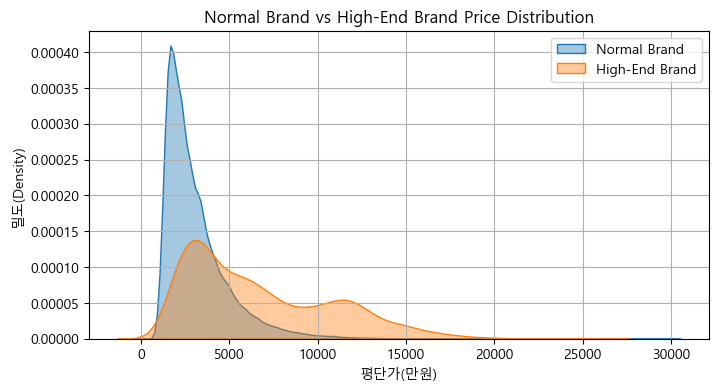

In [143]:

# ==========================================
# 하이엔드 브랜드 데이터만 추출
# ==========================================

highend_df = df[
    df['브랜드'].isin(highend_brand_list)
]

# ==========================================
# 일반 브랜드 데이터 추출
# ==========================================

normal_df = df[
    ~df['브랜드'].isin(highend_brand_list)
]

# ==========================================
# 데이터 개수 확인
# ==========================================

print("하이엔드 브랜드 거래 건수")
print(highend_df.shape)

print()

print("일반 브랜드 거래 건수")
print(normal_df.shape)

# ==========================================
# KDE 그래프 생성
# ==========================================

plt.figure(figsize=(8, 4))

# 일반 브랜드 KDE
sns.kdeplot(
    data=normal_df,
    x='평단가(만원)',
    fill=True,
    alpha=0.4,
    label='Normal Brand'
)

# 하이엔드 브랜드 KDE
sns.kdeplot(
    data=highend_df,
    x='평단가(만원)',
    fill=True,
    alpha=0.4,
    label='High-End Brand'
)

# 제목
plt.title('Normal Brand vs High-End Brand Price Distribution')

# x축
plt.xlabel('평단가(만원)')

# y축
plt.ylabel('밀도(Density)')

# 격자선
plt.grid(True)

# 범례
plt.legend()

# 출력
plt.show()

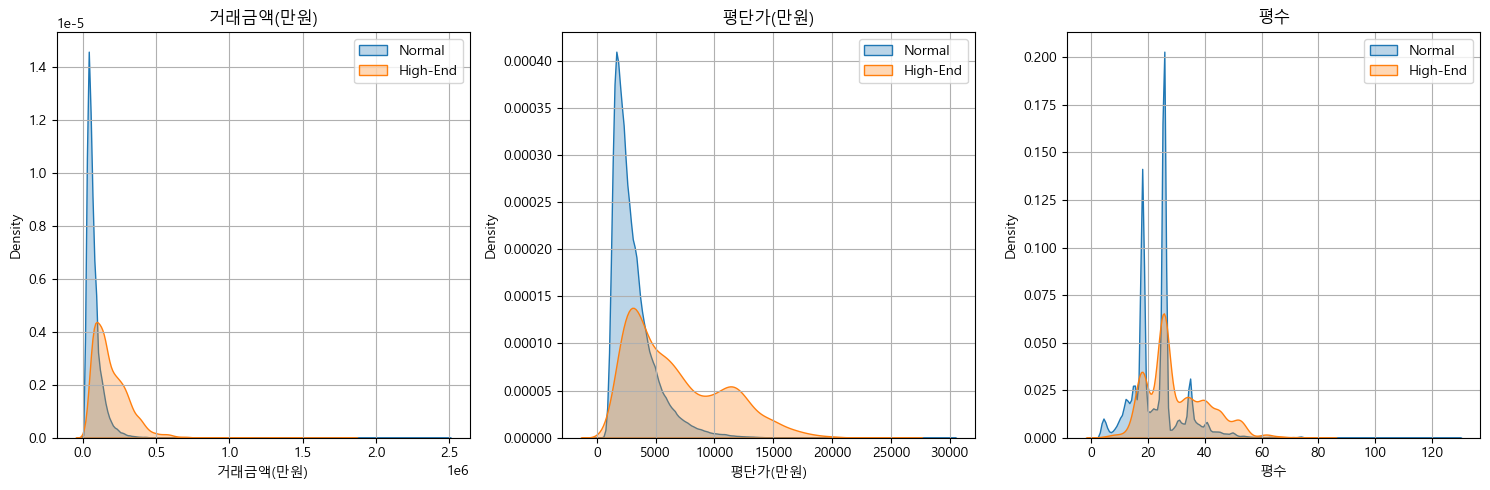

In [144]:
# 아파트 일반 드랜드 분표 비교
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    '거래금액(만원)',
    '평단가(만원)',
    '평수'
]

plt.figure(figsize=(15,5))

for i, feature in enumerate(features, 1):

    plt.subplot(1, 3, i)

    sns.kdeplot(
        data=normal_df,
        x=feature,
        fill=True,
        alpha=0.3,
        label='Normal'
    )

    sns.kdeplot(
        data=highend_df,
        x=feature,
        fill=True,
        alpha=0.3,
        label='High-End'
    )

    plt.title(feature)

    plt.legend()

    plt.grid(True)

plt.tight_layout()

plt.show()

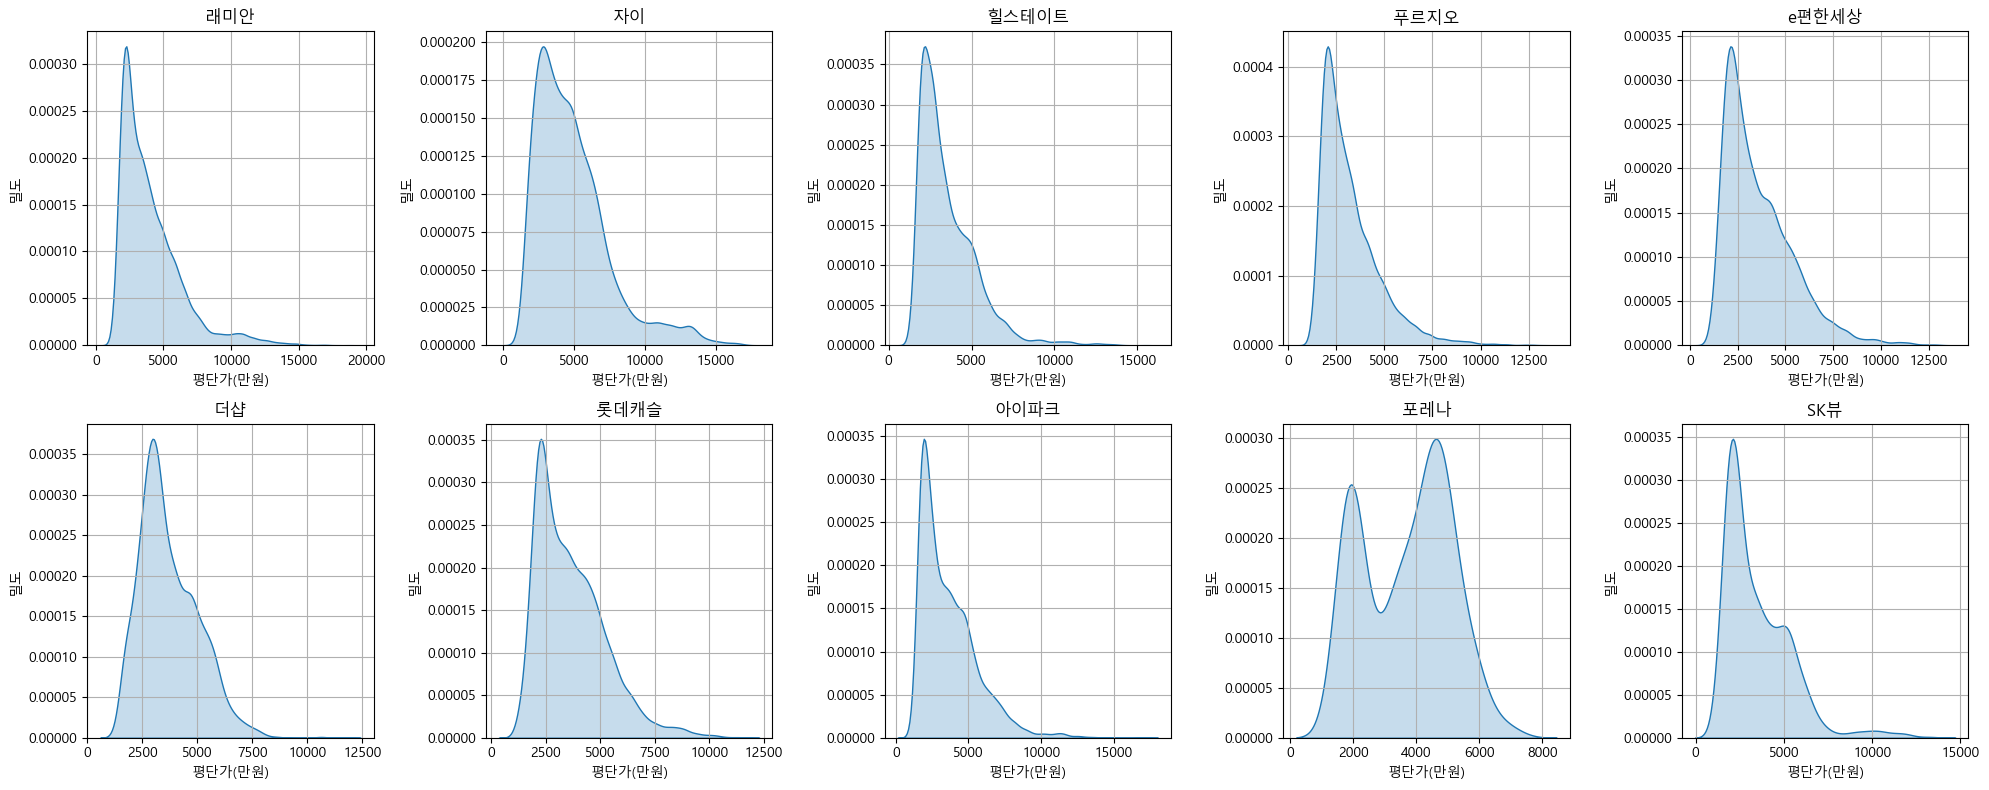

In [146]:
# 일반 브랜드 목록

brand_list = [
    '래미안',
    '자이',
    '힐스테이트',
    '푸르지오',
    'e편한세상',
    '더샵',
    '롯데캐슬',
    '아이파크',
    '포레나',
    'SK뷰'
]

# 그래프 전체 크기

plt.figure(figsize=(20, 8))

# 브랜드별 KDE 생성

for i, brand in enumerate(brand_list, 1):

    # 2행 5열 배치
    plt.subplot(2, 5, i)

    # 해당 브랜드 데이터만 추출
    brand_df = df[
        df['브랜드'] == brand
    ]

    # KDE 그래프
    sns.kdeplot(
        data=brand_df,
        x='평단가(만원)',
        fill=True
    )

    # 그래프 제목
    plt.title(brand)

    # x축 이름
    plt.xlabel('평단가(만원)')

    # y축 이름
    plt.ylabel('밀도')

    # 격자
    plt.grid(True)

plt.tight_layout()

plt.show()

ModuleNotFoundError: No module named 'scipy'

### KDE 보는 법
1. 봉우리 위치
2. 분포 폭
3. 꼬리 길이

### 브랜드별 그래프 해석
1. 래미안 : 봉우리 약 2500~3500 근처 꼬리까지 존재 , 고가 단지와 일반 단지가 함께 존재



In [87]:
df['브랜드'] = df['단지명'].apply(classify_brand)

In [88]:
df['브랜드']

0            기타
1         e편한세상
2            기타
3            기타
4            기타
          ...  
716209       기타
716210       기타
716211       기타
716212       기타
716213       기타
Name: 브랜드, Length: 716214, dtype: str

In [84]:
highend_brand_list = [
    '아크로',
    '오티에르',
    '르엘',
    '드파인',
    '디에이치',
    '써밋',
    '래미안원베일리'
    '레미안원펜타스'
]

### 주요 건설사 브랜드 현황
국내 주요 건설사들은 일반 브랜드와 하이엔드 브랜드를 별도로 운영하고 있다.
하이엔드 브랜드는 고급 주거 시장을 타겟으로 하며, 일바 ㄴ브랜드 보다 높은 분양가야 프리미엄 이미지를 가진다.

| 건설사 | 일반 브랜드 | 하이엔드 브랜드 |
|---------|---------|---------|
| 삼성물산 | 래미안 | 래미안원베일리, 래미안원펜타스 |
| 현대건설·현대엔지니어링 | 힐스테이트 | 디에이치 |
| 대우건설 | 푸르지오 | 써밋 |
| DL E&C | e편한세상 | 아크로 |
| GS건설 | 자이 | 없음 |
| 포스코 E&C | 더샵 | 오티에르 |
| 롯데건설 | 롯데캐슬 | 르엘 |
| SK에코플랜트 | SK뷰 | 드파인 |
| HDC현대산업개발 | 아이파크 | 없음 |
| 한화건설 | 포레나 | 없음 |

In [63]:
# 브랜드 컬럼 생성
df['브랜드'] = '기타'

for brand in brand_list:
    mask = df['단지명'].str.contains(brand, na=False)
    df.loc[mask, '브랜드'] = brand
    

In [64]:
df['단지명'].value_counts().head(300)

단지명
현대           6481
두산           5271
신동아          4680
벽산           4355
주공2          3854
             ... 
월곡래미안루나밸리     506
동부골든          506
건영2           503
우성3           500
흑석한강푸르지오      500
Name: count, Length: 300, dtype: int64

In [65]:
df.head()

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수,계약월,브랜드
0,1,서울특별시 중구 신당동,서울특별시,중구,신당동,840,840,0,현대,79.11,...,1993,다산로36길 109,-,중개거래,서울 중구,25.03.20,아파트,23.93,01,기타
1,2,서울특별시 성동구 행당동,서울특별시,성동구,행당동,347,347,0,대림e-편한세상,114.94,...,2000,행당로 79,-,중개거래,서울 성동구,25.03.28,아파트,34.77,01,e-편한세상
2,3,서울특별시 성북구 동소문동4가,서울특별시,성북구,동소문동4가,279,279,0,송산아파트,58.59,...,1998,동소문로3길 101,-,중개거래,서울 성북구,25.04.02,아파트,17.72,01,기타
3,4,서울특별시 노원구 공릉동,서울특별시,노원구,공릉동,91,91,0,청솔아파트8,84.65,...,2000,노원로1가길 10,-,중개거래,서울 노원구,25.02.26,아파트,25.61,01,기타
4,5,서울특별시 성북구 돈암동,서울특별시,성북구,돈암동,632,632,0,돈암동 풍림아파트 101~105동,84.68,...,1999,북악산로 913,-,중개거래,서울 성북구,25.05.30,아파트,25.62,01,기타


In [66]:
e편한세상 = df[df['단지명'].str.contains('e편한세상', na=False)]

In [67]:
df[df['단지명'].str.contains('이편한', na=False)]

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수,계약월,브랜드
40,41,서울특별시 강서구 화곡동,서울특별시,강서구,화곡동,1159,1159,0,"우장산아이파크,이편한세상",114.980,...,2008,강서로 266,20250401,중개거래,서울 강서구,-,아파트,34.78,12,아이파크
60,61,서울특별시 강서구 화곡동,서울특별시,강서구,화곡동,1159,1159,0,"우장산아이파크,이편한세상",114.980,...,2008,강서로 266,-,중개거래,서울 강서구,25.04.30,아파트,34.78,12,아이파크
1230,1231,서울특별시 동대문구 용두동,서울특별시,동대문구,용두동,795,795,0,이편한세상청계센트럴포레,84.950,...,2021,무학로 91,-,중개거래,서울 동대문구,25.04.25,아파트,25.70,12,기타
1244,1245,서울특별시 중랑구 묵동,서울특별시,중랑구,묵동,396,396,0,이편한세상화랑대,59.953,...,2017,숙선옹주로 45,-,중개거래,서울 중랑구,25.02.04,아파트,18.14,12,기타
1294,1295,서울특별시 마포구 용강동,서울특별시,마포구,용강동,508,508,0,이편한세상마포리버파크,84.980,...,2016,토정로31길 24,-,중개거래,서울 마포구,25.03.19,아파트,25.71,12,기타
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712994,112756,서울특별시 강서구 화곡동,서울특별시,강서구,화곡동,1159,1159,0,"우장산아이파크,이편한세상",59.980,...,2008,강서로 266,-,-,-,-,아파트,18.14,02,아이파크
714309,114071,서울특별시 성북구 보문동3가,서울특별시,성북구,보문동3가,230,230,0,이편한세상보문,59.663,...,2013,낙산길 255,-,-,-,-,아파트,18.05,02,기타
714519,114281,서울특별시 강서구 화곡동,서울특별시,강서구,화곡동,1159,1159,0,"우장산아이파크,이편한세상",84.970,...,2008,강서로 266,-,-,-,-,아파트,25.70,02,아이파크
714899,114661,서울특별시 강서구 화곡동,서울특별시,강서구,화곡동,1159,1159,0,"우장산아이파크,이편한세상",84.970,...,2008,강서로 266,-,-,-,-,아파트,25.70,02,아이파크


In [68]:
'평단가(만원)' in df.columns

True

In [69]:
df['평단가(만원)'] = (df['거래금액(만원)'] / 평수).round(0)

NameError: name '평수' is not defined

In [ ]:
df['평단가(만원)']

0         3844.0
1         4487.0
2         2990.0
3         2656.0
4         2534.0
           ...  
716209    3252.0
716210    3101.0
716211    2717.0
716212    3593.0
716213    3473.0
Name: 평단가(만원), Length: 716214, dtype: float64

In [ ]:
df.head(5)

,NO,시군구,시,구,지역동,번지,본번,부번,단지명,전용면적(㎡),...,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형,평수,계약월,브랜드
0,1,서울특별시 중구 신당동,서울특별시,중구,신당동,840,840,0,현대,79.11,...,1993,다산로36길 109,-,중개거래,서울 중구,25.03.20,아파트,23.93,01,기타
1,2,서울특별시 성동구 행당동,서울특별시,성동구,행당동,347,347,0,대림e-편한세상,114.94,...,2000,행당로 79,-,중개거래,서울 성동구,25.03.28,아파트,34.77,01,e-편한세상
2,3,서울특별시 성북구 동소문동4가,서울특별시,성북구,동소문동4가,279,279,0,송산아파트,58.59,...,1998,동소문로3길 101,-,중개거래,서울 성북구,25.04.02,아파트,17.72,01,기타
3,4,서울특별시 노원구 공릉동,서울특별시,노원구,공릉동,91,91,0,청솔아파트8,84.65,...,2000,노원로1가길 10,-,중개거래,서울 노원구,25.02.26,아파트,25.61,01,기타
4,5,서울특별시 성북구 돈암동,서울특별시,성북구,돈암동,632,632,0,돈암동 풍림아파트 101~105동,84.68,...,1999,북악산로 913,-,중개거래,서울 성북구,25.05.30,아파트,25.62,01,기타


Merge

In [ ]:
file_path = r"C:\Users\INSIGHT\Desktop\DB\Merge_Data"
os.listdir(file_path)

['GDP 대비 통화량 비율.xlsx',
 '금융불안지수 (FSI).xlsx',
 '생산자물가조사.xlsx',
 '예금은행 가계대출금리.xlsx',
 '통화증가율과 인플레이션율.xlsx']

In [ ]:
Merge_file_list = []

In [ ]:
for file in Merge_file_list:
    file 

## 금리에 따른 분석
1. 금리가 낮아지면 대출이 쉬워지고 -> 집 사려는 사람 증가 -> 거래량 증가 -> 집값 상승 
    반대로 금리가 올라가면 대출 부담이 증가하고 -> 매수자 감소 -> 집값 상승세 둔화 -> 집값 하락
실무에서는 가격보다 거래량을 먼

# 시각화

1. 경제성장률
2. 건설투자증감률
3. 설비투자증감률
4. 주택매매가격지수
5. 지가변동률(전기대비)

### 명목 GDP

### 실질 GDP

### 금리에 따른 인상률

### 생산자 물가 지수

### 소비자 물가 지수